# EcoScore Results Analysis

Analysis and visualization of real satellite-derived EcoScores for 40 suppliers across 3 zones.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
print('Libraries imported successfully')

Libraries imported successfully


## 1. Load Results

In [2]:
with open('../results/scores.json', 'r') as f:
    results = json.load(f)

zone_scores = results['zone_scores']
suppliers = results['suppliers']

zones_df = pd.DataFrame([{
    'zone': zone,
    'ecoscore': data['ecoscore'],
    'status': data['status'],
    'deforestation_risk': data['deforestation_risk'],
    'water_stress': data['water_stress'],
    'pollution_proxy': data['pollution_proxy'],
    'ndvi': data['ndvi'],
    'ndwi': data['ndwi']
} for zone, data in zone_scores.items()])

suppliers_df = pd.DataFrame(suppliers)

print(f'Loaded {len(zones_df)} zones and {len(suppliers_df)} suppliers')
print('\nZone Summary:')
print(zones_df[['zone', 'ecoscore', 'status']])
print('\nSupplier Status Distribution:')
print(suppliers_df['status'].value_counts())

Loaded 3 zones and 40 suppliers

Zone Summary:
         zone  ecoscore    status
0    pakistan     31.85  CRITICAL
1       china     43.12    REVIEW
2  bangladesh     54.13    REVIEW

Supplier Status Distribution:
status
REVIEW      23
CRITICAL    17
Name: count, dtype: int64


## 2. Bar Chart - EcoScore by Zone

Saved: results/figures/01_ecoscore_by_zone.png


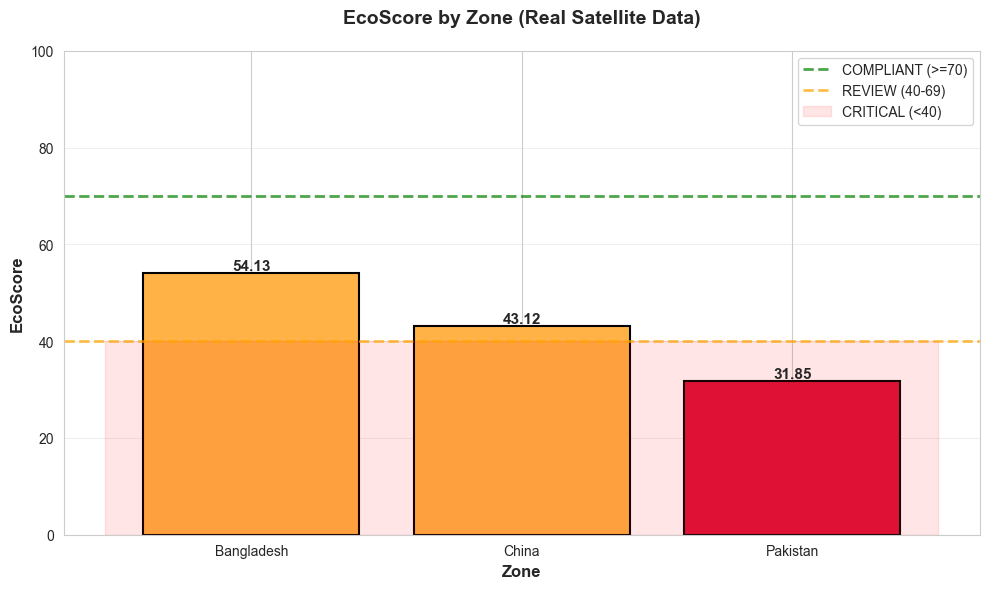

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = {
    'pakistan': '#DC143C',
    'china': '#FFB347',
    'bangladesh': '#FFB347'
}

zones_sorted = zones_df.sort_values('zone')
zone_colors = [colors[zone] for zone in zones_sorted['zone']]

bars = ax.bar(zones_sorted['zone'].str.capitalize(), zones_sorted['ecoscore'],
               color=zone_colors, edgecolor='black', linewidth=1.5)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.axhline(y=70, color='green', linestyle='--', linewidth=2, alpha=0.7, label='COMPLIANT (>=70)')
ax.axhline(y=40, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='REVIEW (40-69)')
ax.fill_between(ax.get_xlim(), 0, 40, alpha=0.1, color='red', label='CRITICAL (<40)')

ax.set_ylabel('EcoScore', fontsize=12, fontweight='bold')
ax.set_xlabel('Zone', fontsize=12, fontweight='bold')
ax.set_title('EcoScore by Zone (Real Satellite Data)', fontsize=14, fontweight='bold', pad=20)
ax.set_ylim(0, 100)
ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
Path('../results/figures').mkdir(parents=True, exist_ok=True)
plt.savefig('../results/figures/01_ecoscore_by_zone.png', dpi=300, bbox_inches='tight')
print('Saved: results/figures/01_ecoscore_by_zone.png')
plt.show()

## 3. Pie Chart - Supplier Status Distribution

Saved: results/figures/02_supplier_status_distribution.png


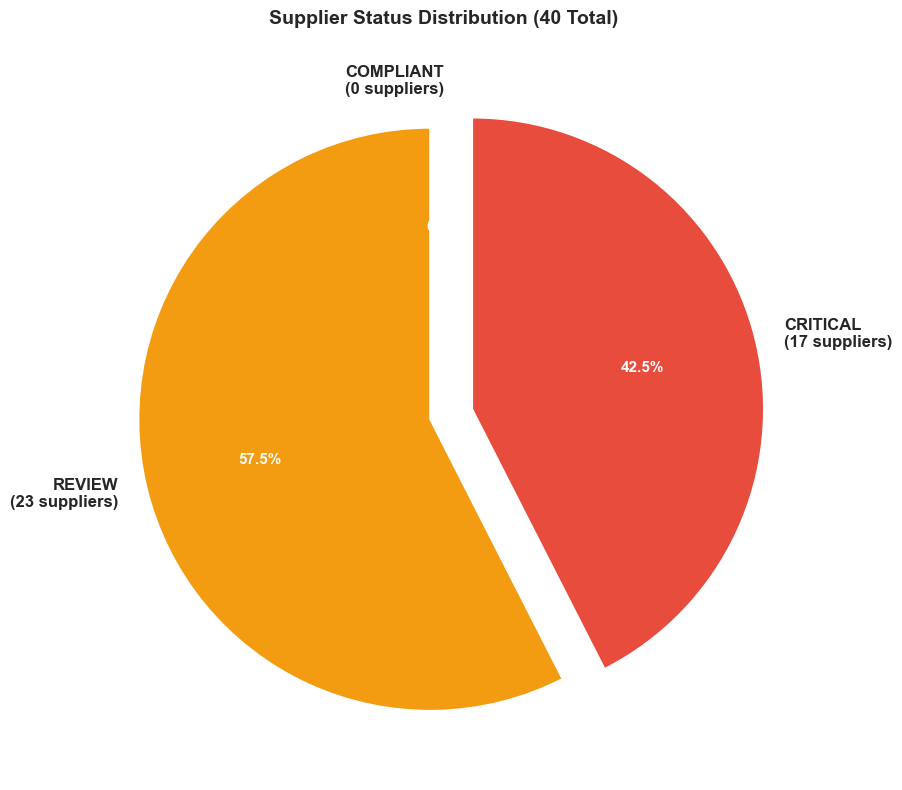


Status Breakdown:
  COMPLIANT: 0 suppliers (0.0%)
  REVIEW: 23 suppliers (57.5%)
  CRITICAL: 17 suppliers (42.5%)


In [4]:
status_counts = suppliers_df['status'].value_counts()
status_order = ['COMPLIANT', 'REVIEW', 'CRITICAL']
status_counts = status_counts.reindex(status_order, fill_value=0)

status_colors = {
    'COMPLIANT': '#2ECC71',
    'REVIEW': '#F39C12',
    'CRITICAL': '#E74C3C'
}
pie_colors = [status_colors[status] for status in status_counts.index]

fig, ax = plt.subplots(figsize=(10, 8))

wedges, texts, autotexts = ax.pie(
    status_counts.values, labels=status_counts.index, autopct='%1.1f%%',
    colors=pie_colors, startangle=90, textprops={'fontsize': 12, 'weight': 'bold'},
    explode=(0.05, 0.05, 0.1)
)

for i, (status, count) in enumerate(zip(status_counts.index, status_counts.values)):
    texts[i].set_text(f'{status}\n({int(count)} suppliers)')

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(11)

ax.set_title('Supplier Status Distribution (40 Total)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()

plt.savefig('../results/figures/02_supplier_status_distribution.png', dpi=300, bbox_inches='tight')
print('Saved: results/figures/02_supplier_status_distribution.png')
plt.show()

print(f'\nStatus Breakdown:')
for status, count in status_counts.items():
    print(f'  {status}: {int(count)} suppliers ({count/len(suppliers_df)*100:.1f}%)')

## 4. Scatter Plot - Water Stress vs Deforestation Risk

Saved: results/figures/03_water_stress_vs_deforestation.png


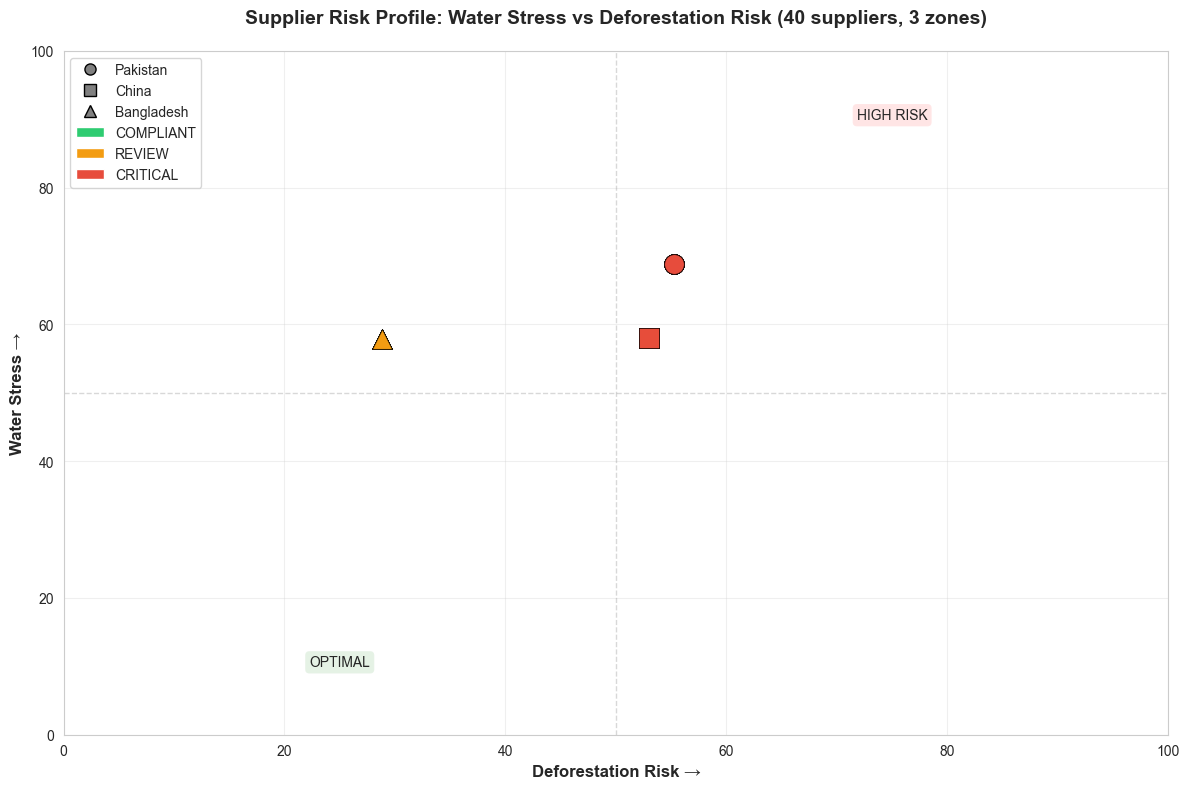

In [5]:
suppliers_df_merged = suppliers_df.merge(
    zones_df[['zone', 'deforestation_risk', 'water_stress']],
    on='zone',
    how='left'
)

fig, ax = plt.subplots(figsize=(12, 8))

status_color_map = {'COMPLIANT': '#2ECC71', 'REVIEW': '#F39C12', 'CRITICAL': '#E74C3C'}
zone_markers = {'pakistan': 'o', 'china': 's', 'bangladesh': '^'}

for zone in ['pakistan', 'china', 'bangladesh']:
    zone_data = suppliers_df_merged[suppliers_df_merged['zone'] == zone]
    for status in ['COMPLIANT', 'REVIEW', 'CRITICAL']:
        status_data = zone_data[zone_data['status'] == status]
        if len(status_data) > 0:
            ax.scatter(
                status_data['deforestation_risk'], status_data['water_stress'],
                s=200, alpha=0.7, c=status_color_map[status],
                marker=zone_markers[zone], edgecolors='black', linewidth=0.5
            )

ax.axhline(y=50, color='gray', linestyle='--', alpha=0.3, linewidth=1)
ax.axvline(x=50, color='gray', linestyle='--', alpha=0.3, linewidth=1)
ax.text(75, 90, 'HIGH RISK', fontsize=10, ha='center', bbox=dict(boxstyle='round', facecolor='red', alpha=0.1))
ax.text(25, 10, 'OPTIMAL', fontsize=10, ha='center', bbox=dict(boxstyle='round', facecolor='green', alpha=0.1))

ax.set_xlabel('Deforestation Risk →', fontsize=12, fontweight='bold')
ax.set_ylabel('Water Stress →', fontsize=12, fontweight='bold')
ax.set_title('Supplier Risk Profile: Water Stress vs Deforestation Risk (40 suppliers, 3 zones)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.grid(alpha=0.3)

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=8, label='Pakistan', markeredgecolor='black'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', markersize=8, label='China', markeredgecolor='black'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='gray', markersize=8, label='Bangladesh', markeredgecolor='black'),
    Patch(facecolor='#2ECC71', label='COMPLIANT'),
    Patch(facecolor='#F39C12', label='REVIEW'),
    Patch(facecolor='#E74C3C', label='CRITICAL')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig('../results/figures/03_water_stress_vs_deforestation.png', dpi=300, bbox_inches='tight')
print('Saved: results/figures/03_water_stress_vs_deforestation.png')
plt.show()

## 5. Summary Statistics

In [6]:
print('='*80)
print('ECOSCORE ANALYSIS SUMMARY')
print('='*80)
print('\nZONE PERFORMANCE:')
print('-'*80)
for _, row in zones_df.sort_values('ecoscore').iterrows():
    zone = row['zone'].capitalize()
    score = row['ecoscore']
    status = row['status']
    deforest = row['deforestation_risk']
    water = row['water_stress']
    print(f'{zone:15} EcoScore: {score:6.2f}  Status: {status:10}  Deforest: {deforest:6.2f}  Water: {water:6.2f}')

print('\n' + '='*80)
print('SUPPLIER STATISTICS')
print('='*80)
print(f'\nTotal Suppliers: {len(suppliers_df)}')
print(f'\nBy Type:')
for supplier_type in suppliers_df['type'].unique():
    count = len(suppliers_df[suppliers_df['type'] == supplier_type])
    print(f'  {supplier_type.capitalize()}: {count}')

print(f'\nBy Status:')
for status in ['COMPLIANT', 'REVIEW', 'CRITICAL']:
    count = len(suppliers_df[suppliers_df['status'] == status])
    pct = count / len(suppliers_df) * 100
    print(f'  {status:10}: {count:3} ({pct:5.1f}%)')

print(f'\nBy Zone:')
for zone in sorted(suppliers_df['zone'].unique()):
    count = len(suppliers_df[suppliers_df['zone'] == zone])
    pct = count / len(suppliers_df) * 100
    print(f'  {zone.capitalize():15}: {count:3} ({pct:5.1f}%)')

print('\n' + '='*80)
print('AUDIT FREQUENCY')
print('='*80)
for freq in sorted(suppliers_df['audit_frequency'].unique()):
    count = len(suppliers_df[suppliers_df['audit_frequency'] == freq])
    print(f'  {freq.capitalize():20}: {count} suppliers')

print('\n' + '='*80)

ECOSCORE ANALYSIS SUMMARY

ZONE PERFORMANCE:
--------------------------------------------------------------------------------
Pakistan        EcoScore:  31.85  Status: CRITICAL    Deforest:  55.26  Water:  68.81
China           EcoScore:  43.12  Status: REVIEW      Deforest:  53.00  Water:  58.07
Bangladesh      EcoScore:  54.13  Status: REVIEW      Deforest:  28.84  Water:  57.89

SUPPLIER STATISTICS

Total Suppliers: 40

By Type:
  Monitored: 25
  Marketplace: 15

By Status:
  COMPLIANT :   0 (  0.0%)
  REVIEW    :  23 ( 57.5%)
  CRITICAL  :  17 ( 42.5%)

By Zone:
  Bangladesh     :  13 ( 32.5%)
  China          :  13 ( 32.5%)
  Pakistan       :  14 ( 35.0%)

AUDIT FREQUENCY
  Annual              : 15 suppliers
  Quarterly           : 25 suppliers



## 6. Verify Figures Saved

In [7]:
figures_dir = Path('../results/figures')
if figures_dir.exists():
    files = list(figures_dir.glob('*.png'))
    print(f'\nFigures directory: {figures_dir}')
    print(f'Saved {len(files)} figures:')
    for file in sorted(files):
        size_mb = file.stat().st_size / (1024*1024)
        print(f'  - {file.name} ({size_mb:.2f} MB)')
else:
    print('Figures directory not found')


Figures directory: ..\results\figures
Saved 3 figures:
  - 01_ecoscore_by_zone.png (0.10 MB)
  - 02_supplier_status_distribution.png (0.14 MB)
  - 03_water_stress_vs_deforestation.png (0.15 MB)
